In [1]:
import json
import pandas as pd
import os
import numpy as np
from scipy import stats as scipy_stats
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("Samples", exist_ok=True)

In [2]:
he_files = ["human", "supernote_lite_gemini-2.5-flash", "web_search_gemini-2.5-flash_T2", "our_gemini-2.5-flash_T2"]

if not os.path.exists("Samples/anonymous_sample.xlsx"):
    tweets = json.load(open("../../Data/tweets.json", encoding="utf-8"))
    notes = {f: json.load(open(f"../../Experiments/Postprocessed Outputs/{f}.json", encoding="utf-8")) for f in he_files}

    tmp = json.load(open("../../Experiments/Outputs/supernote_lite_gpt-5-nano.json", encoding="utf-8"))
    non_NA_notes = [id for id in tmp if tmp[id] != "NA"]

    np.random.seed(42)
    sample_ids = np.random.choice(non_NA_notes, size=100, replace=False)

    df = []
    for i in sample_ids:
        row = {"tweet_id": "TID"+str(i), "tweet_text": tweets[i]["text"], "date": tweets[i]["createdAt"]}
        for f in he_files:
            row["method"] = f
            row["note"] = notes[f][i]
            df.append(row.copy())

    df = pd.DataFrame(df)

    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df = df.sort_values(by=["tweet_id"], kind="mergesort")

    df.to_excel("Samples/non_anonymous_sample.xlsx", index=False)
    df.drop(columns=["method"], inplace=True)

    # add annotation columns
    for ac in ["F1", "F2", "F3", "F4", "C1", "C2", "H", "R"]:
        df[ac] = None

    df.to_excel("Samples/anonymous_sample.xlsx", index=False)
    print("anno_sample.xlsx is the evaluation file, with method names removed and randomly shuffled.")

In [3]:
df = pd.read_excel("Samples/anonymous_sample_annotated.xlsx")
df_method = pd.read_excel("Samples/non_anonymous_sample.xlsx")

df["method"] = df_method["method"]

df

,tweet_id,tweet_text,date,note,F1,F2,F3,F4,C1,C2,H,R,method
0,TID1920086263345873129,Spotted in Austin: “All gender restroom.” On a...,Wed May 07 12:00:13 +0000 2025,All-gender restrooms provide accessibility for...,1,1,1,1,1.0,1,5,1,web_search_gemini-2.5-flash_T2
1,TID1920086263345873129,Spotted in Austin: “All gender restroom.” On a...,Wed May 07 12:00:13 +0000 2025,"""All-Gender Restrooms"" are single-occupancy re...",1,0,0,0,1.0,1,3,2,human
2,TID1920086263345873129,Spotted in Austin: “All gender restroom.” On a...,Wed May 07 12:00:13 +0000 2025,"An ""all gender restroom"" provides access for a...",1,1,0,0,1.0,0,2,4,supernote_lite_gemini-2.5-flash
3,TID1920086263345873129,Spotted in Austin: “All gender restroom.” On a...,Wed May 07 12:00:13 +0000 2025,"While biological sex is generally bimodal, it ...",1,0,0,0,1.0,0,2,3,our_gemini-2.5-flash_T2
4,TID1921059060851294603,The bill is now law. Any activist judge attemp...,Sat May 10 04:25:46 +0000 2025,HR 1526 has only passed the House of Represent...,1,1,1,1,1.0,1,5,2,supernote_lite_gemini-2.5-flash
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,TID1963017828346347921,EPSTEIN FILES!!! https://t.co/Sb753r50g0,Tue Sep 02 23:14:56 +0000 2025,"On Sept 2, 2025, the House Committee released ...",1,1,1,1,1.0,1,3,2,our_gemini-2.5-flash_T2
396,TID1963093030811877861,"Now, imagine if men’s healthcare rights were t...",Wed Sep 03 04:13:45 +0000 2025,The Affordable Care Act mandates coverage for ...,1,1,1,1,0.0,0,2,2,web_search_gemini-2.5-flash_T2
397,TID1963093030811877861,"Now, imagine if men’s healthcare rights were t...",Wed Sep 03 04:13:45 +0000 2025,This photo is from a March 2017 meeting with t...,1,1,1,1,1.0,1,4,1,human
398,TID1963093030811877861,"Now, imagine if men’s healthcare rights were t...",Wed Sep 03 04:13:45 +0000 2025,While no single large-scale White House meetin...,1,0,0,0,0.0,0,2,3,supernote_lite_gemini-2.5-flash


In [4]:
scores = []
for m in he_files:
    tmp = df[df.method == m][["F1", "F2", "F3", "F4", "C1", "C2", "H"]]
    scores.append({**{"method": m}, **(tmp.mean().round(2).to_dict())})

pd.DataFrame(scores).to_csv("human_agg_scores.csv", index=False)
pd.DataFrame(scores)

,method,F1,F2,F3,F4,C1,C2,H
0,human,0.94,0.91,0.87,0.81,0.93,0.69,3.36
1,supernote_lite_gemini-2.5-flash,0.96,0.83,0.73,0.77,0.91,0.53,3.14
2,web_search_gemini-2.5-flash_T2,0.96,0.80,0.89,0.88,0.85,0.65,3.44
3,our_gemini-2.5-flash_T2,0.99,0.89,0.91,0.90,0.97,0.87,3.87


In [5]:
def mean_difference_significance(list1, list2):
    x, y = np.array(list1), np.array(list2)

    _, p_value = scipy_stats.ttest_ind(x, y, equal_var=False)

    if p_value < 0.001:
        sig = "***"   # p < 0.001
    elif p_value < 0.01:
        sig = "**"    # p < 0.01
    elif p_value < 0.05:
        sig = "*"     # p < 0.05
    else:
        sig = "ns"    # not significant

    return p_value, sig

tmp_human = df[df.method == "human"][["F1", "F2", "F3", "F4", "C1", "C2", "H"]]
tmp_our = df[df.method == "our_gemini-2.5-flash_T2"][["F1", "F2", "F3", "F4", "C1", "C2", "H"]]

print("Mean Difference Significance between Human and Our Method:")
for c in tmp_human.columns:
    p_val, sig = mean_difference_significance(list(tmp_human[c]), list(tmp_our[c]))
    print(f"{c}: p-value = {p_val:.4f}, significance = {sig}")

Mean Difference Significance between Human and Our Method:
F1: p-value = 0.0555, significance = ns
F2: p-value = 0.6394, significance = ns
F3: p-value = 0.3686, significance = ns
F4: p-value = 0.0714, significance = ns
C1: p-value = 0.1965, significance = ns
C2: p-value = 0.0020, significance = **
H: p-value = 0.0059, significance = **


In [6]:
df_sub = df[["tweet_id", "method", "R"]].copy()

pivot = df_sub.pivot(
    index="tweet_id",
    columns="method",
    values="R"
)

In [7]:
methods = ['human', 'supernote_lite_gemini-2.5-flash', 'web_search_gemini-2.5-flash_T2', 'our_gemini-2.5-flash_T2']
win_matrix = pd.DataFrame(
    index=methods,
    columns=methods,
    dtype=float
)

for m1 in methods:
    for m2 in methods:
        if m1 == m2:
            win_matrix.loc[m1, m2] = None #(pivot[m1] < pivot["human"]).mean()
            continue

        win_matrix.loc[m1, m2] = (pivot[m1] < pivot[m2]).mean()

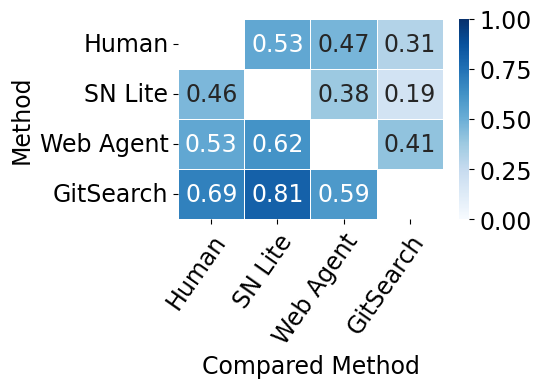

In [8]:
plt.figure(figsize=(5.5, 4.2))
plt.rcParams["font.size"] = 17
sns.heatmap(
    win_matrix,
    annot=True,
    # mask=np.triu(np.ones_like(win_matrix, dtype=bool), k=1),
    fmt=".2f",
    cmap="Blues",
    center=0.5,
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.xlabel("Compared Method")
plt.xticks(ticks=[0.5,1.5,2.5,3.5], labels=["Human", "SN Lite", "Web Agent", "GitSearch"], rotation=55, ha="right", rotation_mode="anchor")
plt.ylabel("Method")
plt.yticks(ticks=[0.5,1.5,2.5,3.5], labels=["Human", "SN Lite", "Web Agent", "GitSearch"], rotation=0)
plt.tight_layout()
plt.savefig("win_rate_heatmap.pdf")